# Step 3 — Data Analysis and Visualization
**LB2 Project · Group 7 · Signal Peptide Prediction**

### Objective
Understand the structure and biological characteristics of the dataset **before** training any model.
Good exploratory analysis helps us:
- Confirm the dataset is biologically coherent and annotation-correct
- Detect biases (taxonomic, length-based, compositional)
- Identify features that will be informative for classification

### Analyses performed
| # | Analysis | Dataset |
|---|---|---|
| 1 | Protein length distribution | Positive vs Negative |
| 2 | Signal peptide length distribution | Positive only |
| 3 | Amino acid composition vs SwissProt background | Positive SP region vs Negative N-term |
| 4 | Taxonomic (kingdom) distribution | Positive vs Negative |
| 5 | Cleavage site sequence logo | Positive only |

### Input files
- `training_with_folds.tsv` — training set with labels
- `benchmarking_set.tsv` — benchmark set with labels
- `positive.fasta` — full sequences for the positive set (needed for AA composition and logo)
- `negative.fasta` — full sequences for the negative set

---
## Cell 1 — Install dependencies

In [1]:
!pip install -q biopython pandas numpy matplotlib seaborn logomaker
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 82.7 MB/s eta 0:00:00
Done.


---
## Cell 2 — Imports and global plot settings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import logomaker
from Bio import SeqIO
import os
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE = {'Positive (SP+)': '#2196F3', 'Negative (SP-)': '#F44336'}
os.makedirs('figures', exist_ok=True)

print('Imports OK.')

Imports OK.


---
## Cell 3 — Load data

In [3]:
# Load metadata
df_train = pd.read_csv('training_with_folds.tsv', sep='\t')
df_bench = pd.read_csv('benchmarking_set.tsv',    sep='\t')

# Combine train + benchmark for dataset-wide analyses
df_all = pd.concat([df_train, df_bench], ignore_index=True)

# Separate by label
df_pos = df_all[df_all['label'] == 1].copy()
df_neg = df_all[df_all['label'] == 0].copy()

# Load FASTA sequences into dicts: {accession: sequence}
pos_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse('positive.fasta', 'fasta')}
neg_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse('negative.fasta', 'fasta')}

print(f'Total sequences: {len(df_all):,}')
print(f'  Positive (SP+): {len(df_pos):,}')
print(f'  Negative (SP-): {len(df_neg):,}')
print(f'Positive FASTA loaded: {len(pos_seqs):,}')
print(f'Negative FASTA loaded: {len(neg_seqs):,}')

Total sequences: 10,027
  Positive (SP+): 1,093
  Negative (SP-): 8,934
Positive FASTA loaded: 2,932
Negative FASTA loaded: 20,615


---
## Analysis 1 — Protein length distribution

**Goal:** Compare full protein lengths between SP+ and SP- proteins.  
**Expected:** SP+ proteins tend to be shorter on average than SP− proteins. Cytosolic and nuclear proteins (which make up much of the SP− set) are often large multi-domain enzymes and structural proteins, while many secreted proteins are relatively compact. A length difference between the two classes is expected, but it is not a reliable classifier on its own.

Sequence length summary:
  SP+  mean=396  median=273  min=46  max=5263
  SP-  mean=578  median=424  min=40  max=34350


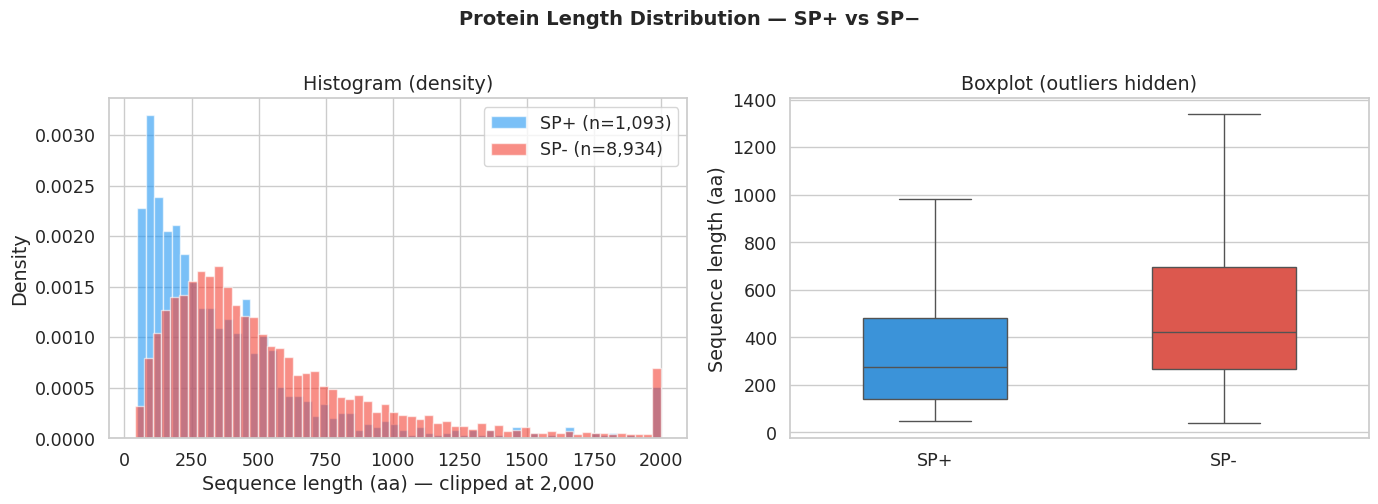

Saved: figures/01_protein_length.pdf/.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Protein Length Distribution — SP+ vs SP−', fontsize=14, fontweight='bold', y=1.01)

lengths_pos = df_pos['Sequence length']
lengths_neg = df_neg['Sequence length']

# --- Left: Histogram (clipped at 2000 for readability) ---
ax = axes[0]
clip = 2000
ax.hist(lengths_pos.clip(upper=clip), bins=60, alpha=0.6,
        color=PALETTE['Positive (SP+)'], label=f'SP+ (n={len(lengths_pos):,})', density=True)
ax.hist(lengths_neg.clip(upper=clip), bins=60, alpha=0.6,
        color=PALETTE['Negative (SP-)'], label=f'SP- (n={len(lengths_neg):,})', density=True)
ax.set_xlabel('Sequence length (aa) — clipped at 2,000')
ax.set_ylabel('Density')
ax.set_title('Histogram (density)')
ax.legend()

# --- Right: Boxplot ---
ax2 = axes[1]
plot_df = pd.DataFrame({
    'Length': pd.concat([lengths_pos, lengths_neg], ignore_index=True),
    'Class': ['SP+'] * len(lengths_pos) + ['SP-'] * len(lengths_neg)
})
sns.boxplot(data=plot_df, x='Class', y='Length', ax=ax2,
            palette={'SP+': PALETTE['Positive (SP+)'], 'SP-': PALETTE['Negative (SP-)']},
            showfliers=False, width=0.5)
ax2.set_xlabel('')
ax2.set_ylabel('Sequence length (aa)')
ax2.set_title('Boxplot (outliers hidden)')

# Print summary stats
print('Sequence length summary:')
print(f'  SP+  mean={lengths_pos.mean():.0f}  median={lengths_pos.median():.0f}  '
      f'min={lengths_pos.min()}  max={lengths_pos.max()}')
print(f'  SP-  mean={lengths_neg.mean():.0f}  median={lengths_neg.median():.0f}  '
      f'min={lengths_neg.min()}  max={lengths_neg.max()}')

plt.tight_layout()
plt.savefig('figures/01_protein_length.pdf', bbox_inches='tight')
plt.savefig('figures/01_protein_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/01_protein_length.pdf/.png')

---
## Analysis 2 — Signal peptide length distribution

**Goal:** Examine the lengths of the signal peptides themselves (positive set only).  
**Expected:** Most SPs are 15–30 aa, with a peak around 20–25, reflecting the hydrophobic core length needed to span the translocon channel.

SP length summary:
  n=1093  mean=22.9  median=22  min=14  max=64
  90% of SPs are between 16 and 33 aa


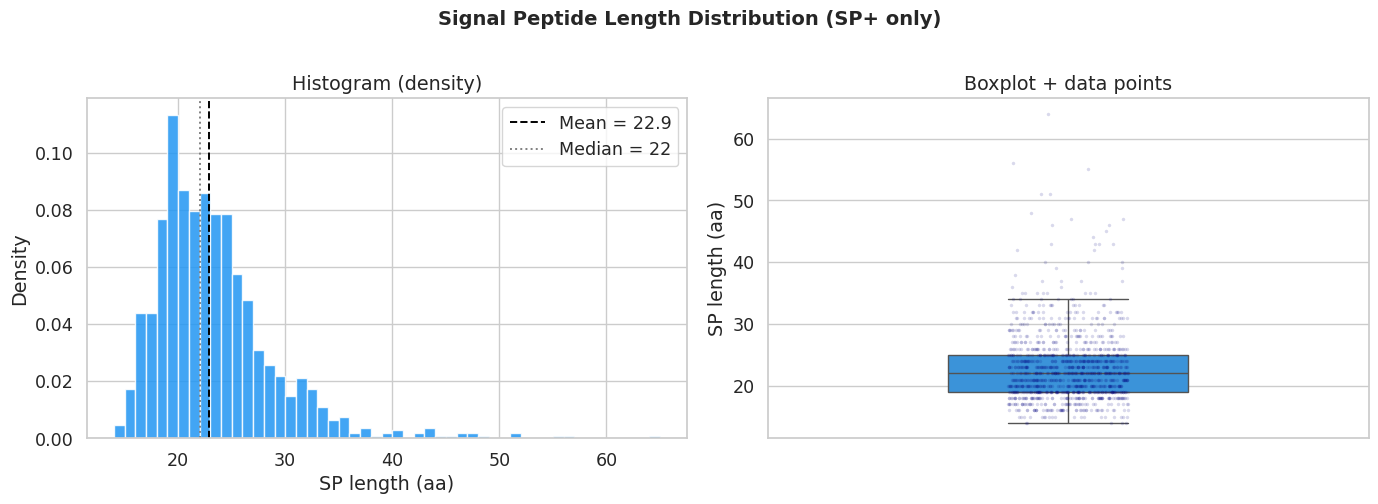

Saved: figures/02_sp_length.pdf/.png


In [5]:
sp_lengths = df_pos['SP cleavage'].dropna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Signal Peptide Length Distribution (SP+ only)', fontsize=14, fontweight='bold', y=1.01)

# --- Histogram ---
ax = axes[0]
ax.hist(sp_lengths, bins=range(sp_lengths.min(), sp_lengths.max() + 2),
        color=PALETTE['Positive (SP+)'], edgecolor='white', alpha=0.85, density=True)
ax.axvline(sp_lengths.mean(),   color='black', linestyle='--', linewidth=1.4, label=f'Mean = {sp_lengths.mean():.1f}')
ax.axvline(sp_lengths.median(), color='gray',  linestyle=':',  linewidth=1.4, label=f'Median = {sp_lengths.median():.0f}')
ax.set_xlabel('SP length (aa)')
ax.set_ylabel('Density')
ax.set_title('Histogram (density)')
ax.legend()

# --- Boxplot + strip ---
ax2 = axes[1]
sns.boxplot(y=sp_lengths, ax=ax2, color=PALETTE['Positive (SP+)'],
            width=0.4, showfliers=False)
sns.stripplot(y=sp_lengths, ax=ax2, color='navy', alpha=0.15, size=2.5, jitter=True)
ax2.set_ylabel('SP length (aa)')
ax2.set_title('Boxplot + data points')
ax2.set_xticks([])

print('SP length summary:')
print(f'  n={len(sp_lengths)}  mean={sp_lengths.mean():.1f}  median={sp_lengths.median():.0f}  '
      f'min={sp_lengths.min()}  max={sp_lengths.max()}')
print(f'  90% of SPs are between {sp_lengths.quantile(0.05):.0f} and {sp_lengths.quantile(0.95):.0f} aa')

plt.tight_layout()
plt.savefig('figures/02_sp_length.pdf', bbox_inches='tight')
plt.savefig('figures/02_sp_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/02_sp_length.pdf/.png')

---
## Analysis 3 — Amino acid composition

**Goal:** Compare the amino acid frequencies of signal peptide regions vs the SwissProt background.  
**Expected:** SPs should be enriched in hydrophobic residues (L, I, V, A, F, M) and depleted in charged/polar residues — this reflects the hydrophobic core needed for membrane insertion.

For positive sequences: we analyse only the **SP region** (first `SP cleavage` positions).  
For negative sequences: we analyse only the **first 30 aa** (the N-terminal region equivalent to where an SP would be).

SwissProt background frequencies are taken from: https://web.expasy.org/docs/relnotes/relstat.html

In [6]:
# SwissProt background amino acid frequencies (from ExPASy release statistics)
SWISSPROT_FREQ = {
    'A': 0.0825, 'R': 0.0553, 'N': 0.0406, 'D': 0.0545, 'C': 0.0138,
    'Q': 0.0393, 'E': 0.0672, 'G': 0.0707, 'H': 0.0228, 'I': 0.0591,
    'L': 0.0965, 'K': 0.0580, 'M': 0.0241, 'F': 0.0386, 'P': 0.0475,
    'S': 0.0664, 'T': 0.0535, 'W': 0.0109, 'Y': 0.0291, 'V': 0.0686
}
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')  # alphabetical


def compute_aa_freq(sequences):
    """Count amino acid frequencies in a list of sequences. Returns dict of frequencies."""
    counts = {aa: 0 for aa in AA_ORDER}
    total = 0
    for seq in sequences:
        for aa in seq.upper():
            if aa in counts:
                counts[aa] += 1
                total += 1
    return {aa: counts[aa] / total for aa in AA_ORDER} if total > 0 else counts


# Extract SP regions from positive sequences
sp_regions = []
for _, row in df_pos.iterrows():
    acc = row['Accession']
    cleavage = int(row['SP cleavage'])
    if acc in pos_seqs:
        sp_regions.append(pos_seqs[acc][:cleavage])

# Extract N-terminal 30 aa from negative sequences
neg_nterm = []
for _, row in df_neg.iterrows():
    acc = row['Accession']
    if acc in neg_seqs:
        neg_nterm.append(neg_seqs[acc][:30])

freq_sp  = compute_aa_freq(sp_regions)
freq_neg = compute_aa_freq(neg_nterm)

print(f'SP regions extracted    : {len(sp_regions)}')
print(f'Negative N-terms (30aa) : {len(neg_nterm)}')

SP regions extracted    : 1093
Negative N-terms (30aa) : 8934


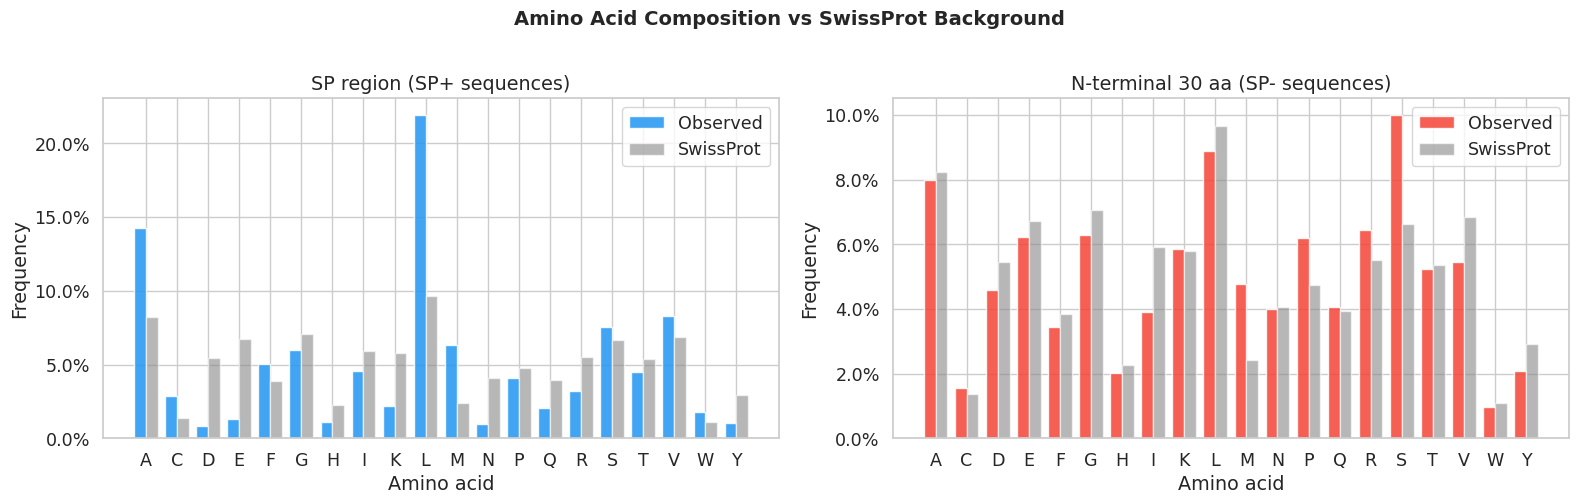

Saved: figures/03_aa_composition.pdf/.png

Top 5 enriched in SP region  : ['M', 'L', 'C', 'A', 'W']
Top 5 depleted in SP region  : ['D', 'E', 'N', 'Y', 'K']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
fig.suptitle('Amino Acid Composition vs SwissProt Background', fontsize=14, fontweight='bold', y=1.01)

x = np.arange(len(AA_ORDER))
width = 0.38

for ax, (freq, title, color) in zip(axes, [
    (freq_sp,  'SP region (SP+ sequences)',        PALETTE['Positive (SP+)']),
    (freq_neg, 'N-terminal 30 aa (SP- sequences)', PALETTE['Negative (SP-)'])
]):
    obs  = [freq[aa]           for aa in AA_ORDER]
    back = [SWISSPROT_FREQ[aa] for aa in AA_ORDER]

    ax.bar(x - width/2, obs,  width, label='Observed', color=color,   alpha=0.85)
    ax.bar(x + width/2, back, width, label='SwissProt', color='#888', alpha=0.60)
    ax.set_xticks(x)
    ax.set_xticklabels(AA_ORDER)
    ax.set_xlabel('Amino acid')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.savefig('figures/03_aa_composition.pdf', bbox_inches='tight')
plt.savefig('figures/03_aa_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/03_aa_composition.pdf/.png')

# Print top enriched AAs in SP region
enrichment = {aa: freq_sp[aa] / SWISSPROT_FREQ[aa] for aa in AA_ORDER}
top_enriched = sorted(enrichment, key=enrichment.get, reverse=True)[:5]
top_depleted = sorted(enrichment, key=enrichment.get)[:5]
print(f'\nTop 5 enriched in SP region  : {top_enriched}')
print(f'Top 5 depleted in SP region  : {top_depleted}')

---
## Analysis 4 — Taxonomic (kingdom) distribution

**Goal:** Check whether the dataset is taxonomically diverse and whether the kingdom composition differs between SP+ and SP- proteins.  
**Expected:** Both sets dominated by Metazoa (animals), with Viridiplantae (plants) and Fungi as secondary kingdoms. The distribution should be similar between SP+ and SP- to avoid taxonomic bias.

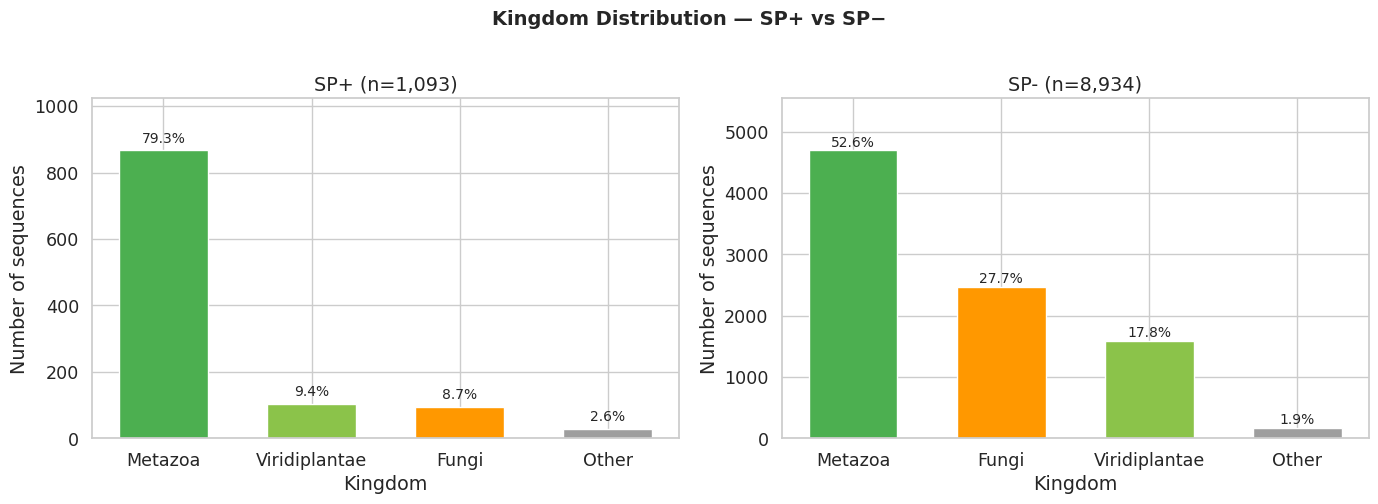

Saved: figures/04_kingdom_distribution.pdf/.png

Kingdom percentages:
  SP+: Metazoa=79.3%  Viridiplantae=9.4%  Fungi=8.7%  Other=2.6%
  SP-: Metazoa=52.6%  Fungi=27.7%  Viridiplantae=17.8%  Other=1.9%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kingdom Distribution — SP+ vs SP−', fontsize=14, fontweight='bold', y=1.01)

kingdom_colors = {
    'Metazoa':      '#4CAF50',
    'Viridiplantae':'#8BC34A',
    'Fungi':        '#FF9800',
    'Other':        '#9E9E9E'
}

for ax, (df_sub, title) in zip(axes, [
    (df_pos, f'SP+ (n={len(df_pos):,})'),
    (df_neg, f'SP- (n={len(df_neg):,})')
]):
    counts = df_sub['Kingdom'].value_counts()
    pcts   = counts / counts.sum() * 100
    colors = [kingdom_colors.get(k, '#BDBDBD') for k in counts.index]

    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.6)
    # Add percentage labels on top of each bar
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('Kingdom')
    ax.set_ylabel('Number of sequences')
    ax.set_ylim(0, counts.max() * 1.18)

plt.tight_layout()
plt.savefig('figures/04_kingdom_distribution.pdf', bbox_inches='tight')
plt.savefig('figures/04_kingdom_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_kingdom_distribution.pdf/.png')

# Print percentage table
print('\nKingdom percentages:')
for label_val, group_name in [(1, 'SP+'), (0, 'SP-')]:
    sub = df_all[df_all['label'] == label_val]
    vc  = sub['Kingdom'].value_counts(normalize=True) * 100
    print(f'  {group_name}: ' + '  '.join(f'{k}={v:.1f}%' for k, v in vc.items()))

---
## Analysis 5 — Cleavage site sequence logo

**Goal:** Visualize the conserved amino acid patterns immediately around the signal peptide cleavage site.  
**Method:** Extract a window from position −13 to +2 relative to the cleavage site (last SP residue at −1, first mature protein residue at +1). Build a position frequency matrix and display as a sequence logo.

**Expected:** Strong conservation of small neutral residues (Ala, Gly, Ser) at −1 and −3, consistent with **von Heijne's −1/−3 rule** for signal peptidase recognition.

In [9]:
WINDOW_BEFORE = 13   # positions before cleavage site
WINDOW_AFTER  = 2    # positions after cleavage site
WINDOW_SIZE   = WINDOW_BEFORE + WINDOW_AFTER  # = 15 total positions

cleavage_windows = []
skipped = 0

for _, row in df_pos.iterrows():
    acc      = row['Accession']
    cleavage = int(row['SP cleavage'])  # 1-indexed: last SP residue

    if acc not in pos_seqs:
        skipped += 1
        continue

    seq   = pos_seqs[acc]
    start = cleavage - WINDOW_BEFORE      # 0-indexed start
    end   = cleavage + WINDOW_AFTER       # 0-indexed end (exclusive)

    # Skip sequences where the window would extend outside the sequence
    if start < 0 or end > len(seq):
        skipped += 1
        continue

    window = seq[start:end].upper()
    if len(window) == WINDOW_SIZE and all(aa in 'ACDEFGHIKLMNPQRSTVWY' for aa in window):
        cleavage_windows.append(window)

print(f'Windows extracted : {len(cleavage_windows)}')
print(f'Skipped           : {skipped}')
print(f'Window example    : {cleavage_windows[0]} (positions -13 to +2)')

Windows extracted : 1092
Skipped           : 0
Window example    : LIYILWQLTGSAASG (positions -13 to +2)


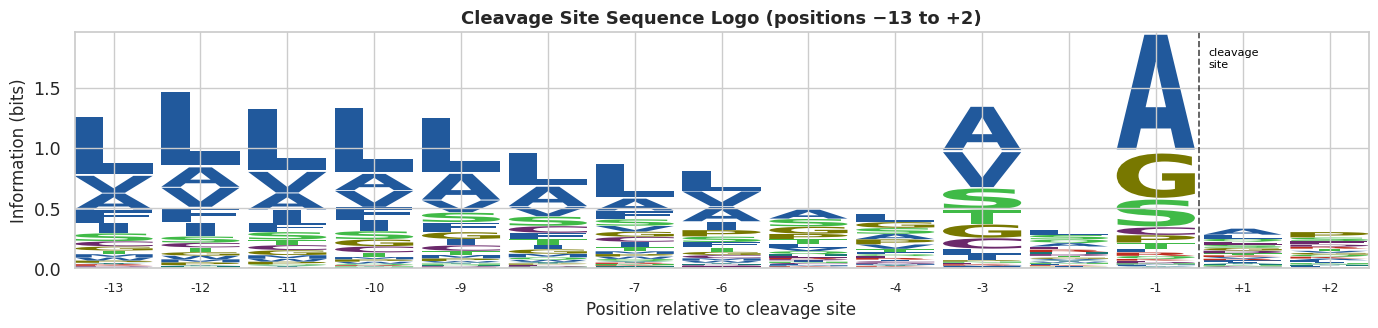

Saved: figures/05_cleavage_site_logo.pdf/.png

Most frequent residue at -1 : A (51.0%)
Most frequent residue at -3 : A (28.0%)
Most frequent residue at +1 : A  (15.9%)


In [13]:
# Build position frequency matrix (PFM) and convert to probability matrix (PPM)
WINDOW_SIZE = WINDOW_BEFORE + WINDOW_AFTER  # = 15 total positions

# Count frequencies at each position
pfm = pd.DataFrame(0, index=list('ACDEFGHIKLMNPQRSTVWY'),
                   columns=range(WINDOW_SIZE))

for window in cleavage_windows:
    for pos, aa in enumerate(window):
        if aa in pfm.index:
            pfm.loc[aa, pos] += 1

# Convert to probability matrix (normalize each column)
# ppm shape: (15 positions, 20 AAs) — logomaker needs integer index
ppm = pfm.div(pfm.sum(axis=0), axis=1).T
ppm.index = range(WINDOW_SIZE)  # logomaker requires integer index

# Build information content matrix
logo_df = logomaker.transform_matrix(ppm, from_type='probability', to_type='information')

fig, ax = plt.subplots(figsize=(14, 3.5))
logo = logomaker.Logo(
    logo_df,
    ax=ax,
    color_scheme='NajafabadiEtAl2017',
    vpad=0.05,
    width=0.9
)

# X-axis tick labels: -13, -12, ..., -1, +1, +2
x_labels = [str(i) for i in range(-WINDOW_BEFORE, 0)] + ['+1', '+2']
ax.set_xticks(range(WINDOW_SIZE))
ax.set_xticklabels(x_labels, fontsize=9)

# Vertical line at cleavage site (between position index 12 and 13)
ax.axvline(x=WINDOW_BEFORE - 0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(WINDOW_BEFORE - 0.4, ax.get_ylim()[1] * 0.85,
        'cleavage\nsite', fontsize=8, color='black', ha='left')

ax.set_xlabel('Position relative to cleavage site', fontsize=12)
ax.set_ylabel('Information (bits)', fontsize=12)
ax.set_title('Cleavage Site Sequence Logo (positions −13 to +2)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/05_cleavage_site_logo.pdf', bbox_inches='tight')
plt.savefig('figures/05_cleavage_site_logo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/05_cleavage_site_logo.pdf/.png')

# Print most conserved residues at key positions (using integer index)
pos_minus1 = WINDOW_BEFORE - 1   # index 12 = position -1
pos_minus3 = WINDOW_BEFORE - 3   # index 10 = position -3
pos_plus1  = WINDOW_BEFORE       # index 13 = position +1

print(f'\nMost frequent residue at -1 : {ppm.loc[pos_minus1].idxmax()} ({ppm.loc[pos_minus1].max()*100:.1f}%)')
print(f'Most frequent residue at -3 : {ppm.loc[pos_minus3].idxmax()} ({ppm.loc[pos_minus3].max()*100:.1f}%)')
print(f'Most frequent residue at +1 : {ppm.loc[pos_plus1].idxmax()}  ({ppm.loc[pos_plus1].max()*100:.1f}%)')

---
## Summary

In [15]:
import os

sep = '=' * 58
print(sep)
print('  DATA ANALYSIS SUMMARY — LB2 Group 7')
print(sep)
print()
print('  Dataset overview')
print(f'    Total sequences   : {len(df_all):,}')
print(f'    SP+ (positive)    : {len(df_pos):,}')
print(f'    SP- (negative)    : {len(df_neg):,}')
print()
print('  Key findings')
print(f'    Protein length    : SP+ median={df_pos["Sequence length"].median():.0f} aa,'
      f' SP- median={df_neg["Sequence length"].median():.0f} aa')
print(f'    SP length         : mean={sp_lengths.mean():.1f} aa, range {sp_lengths.min()}–{sp_lengths.max()} aa')
print(f'    SP enriched AAs   : {top_enriched} (vs SwissProt background)')
print(f'    SP depleted AAs   : {top_depleted}')
print(f'    Cleavage -1 pos   : {ppm.loc[WINDOW_BEFORE - 1].idxmax()} ({ppm.loc[WINDOW_BEFORE - 1].max()*100:.1f}%) — supports von Heijne rule')
print()
print('  Output figures saved to figures/')
for f in sorted(os.listdir('figures')):
    print(f'    {f}')
print()
print(sep)

  DATA ANALYSIS SUMMARY — LB2 Group 7

  Dataset overview
    Total sequences   : 10,027
    SP+ (positive)    : 1,093
    SP- (negative)    : 8,934

  Key findings
    Protein length    : SP+ median=273 aa, SP- median=424 aa
    SP length         : mean=22.9 aa, range 14–64 aa
    SP enriched AAs   : ['M', 'L', 'C', 'A', 'W'] (vs SwissProt background)
    SP depleted AAs   : ['D', 'E', 'N', 'Y', 'K']
    Cleavage -1 pos   : A (51.0%) — supports von Heijne rule

  Output figures saved to figures/
    01_protein_length.pdf
    01_protein_length.png
    02_sp_length.pdf
    02_sp_length.png
    03_aa_composition.pdf
    03_aa_composition.png
    04_kingdom_distribution.pdf
    04_kingdom_distribution.png
    05_cleavage_site_logo.pdf
    05_cleavage_site_logo.png

